## Diseño del modelo de CNN como calsificador binario

Loss (Función de pérdida): Binary Crossentropy
✔ Optimizador: Adam
✔ Inicialización: Glorot Uniform
✔ CNN:
- Activación convolucional: tanh
- Activación capas densas: ReLU
- Mismo nº filtros, kernel y pool en todas las conv layers
- MaxPooling = 2
- Máx 10 capas convolucionales

✔ Capa Densa:

Cada capa tiene la mitad de neuronas que la anterior

✔ Entrenamiento:

Dataset balanceado (light vs dark): 1000 light y 1000 dark

Split: 80% train / 20% validation

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, initializers
from sklearn.model_selection import train_test_split

I0000 00:00:1773930981.751183    6528 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773930986.825174    6528 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773931001.566617    6528 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
tree_light_data = uproot.open("TES1-0.3RN-5GHz-50MHz-laser-5s-trigger-10mV.root")["alazar_data"]
tree_light_parameters = uproot.open("TES1-0.3RN-5GHz-50MHz-laser-5s-trigger-10mV.root")["alazar_parameters"]
tree_dark_data = uproot.open("TES1-0.3RN-5GHz-50MHz-extrinsic-2d-trigger-10mV.root")["alazar_data"]
tree_dark_parameters = uproot.open("TES1-0.3RN-5GHz-50MHz-extrinsic-2d-trigger-10mV.root")["alazar_parameters"]
light_pulses = tree_light_data["dataChA"].array(library="np")
dark_pulses = tree_dark_data["dataChA"].array(library="np")

In [4]:
import matplotlib.ticker as ticker

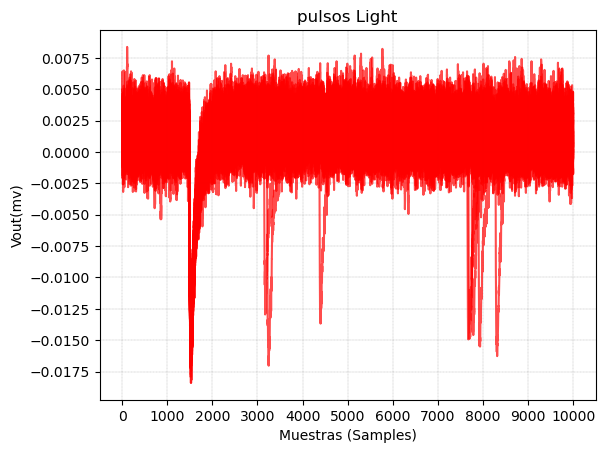

In [5]:
for i in range(50):
    plt.plot(light_pulses[i], alpha = 0.7, color = 'red')
plt.title("pulsos Light")
plt.xlabel("Muestras (Samples)")
plt.ylabel("Vout(mv)")
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.2)
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
plt.show()

In [1]:
#Momentaneamente vamos a trabajar con los 4722 pulsos
# Division del conjunto de datos
n_samples = 1000

X_light = light_pulses[:n_samples] # de 0 a n_samples-1
X_dark = dark_pulses[:n_samples]
print(X_light.shape)
print(type(X_light))

NameError: name 'light_pulses' is not defined

In [8]:
print(X_light)
print(type(X_light))
print(X_dark.shape)

[array([0.0035668 , 0.00314717, 0.00379568, ..., 0.00322347, 0.00295644,
        0.00288014], shape=(10000,))
 array([ 5.14991989e-04,  4.76844434e-04,  3.24254215e-04, ...,
        -9.53688869e-05, -1.33516442e-04, -4.38696880e-04], shape=(10000,))
 array([-0.00181201, -0.00165942, -0.00112535, ...,  0.00078202,
         0.0003624 ,  0.00040055], shape=(10000,))
 array([0.00341421, 0.00329976, 0.00341421, ..., 0.00295644, 0.00329976,
        0.00310903], shape=(10000,))
 array([-9.72762646e-04, -4.76844434e-04, -1.01091020e-03, ...,
         5.72213321e-05, -9.53688869e-05,  9.34615091e-04], shape=(10000,))
 array([ 0.0004387 ,  0.0011635 ,  0.00085832, ..., -0.00028611,
        -0.00059129,  0.00024796], shape=(10000,))
 array([-0.00028611, -0.00131609, -0.00150683, ...,  0.00020981,
         0.00104906,  0.0012398 ], shape=(10000,))
 array([0.00223163, 0.00215534, 0.00211719, ..., 0.00257496, 0.00265126,
        0.00230793], shape=(10000,))
 array([0.00230793, 0.00295644, 0.00215534

In [ ]:

# Etiquetas: los pulsos light tendrán etiqueta 1 y los dark 0
y_light = np.ones(n_samples)
y_dark = np.zeros(n_samples)

In [13]:
print(y_light)
print(y_dark[0])
print(y_light.shape)
print(type(y_light))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.

In [14]:

# Combinar
X = np.concatenate([X_light, X_dark], axis=0)
y = np.concatenate([y_light, y_dark], axis=0)

# Shuffle
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]


In [19]:
print(X)
print(X.shape)

[array([3.14717327e-03, 4.21530480e-03, 4.36789502e-03, ...,
        3.62401770e-04, 9.53688869e-05, 2.09811551e-04], shape=(10000,))
 array([0.0035668 , 0.00402457, 0.00387198, ..., 0.0026894 , 0.00226978,
        0.00211719], shape=(10000,))
 array([0.00246052, 0.00162127, 0.00093462, ..., 0.0019646 , 0.00219348,
        0.00169757], shape=(10000,))
 ...
 array([0.00288014, 0.00265126, 0.00261311, ..., 0.0019646 , 0.00215534,
        0.00230793], shape=(10000,))
 array([ 6.67582208e-04,  5.72213321e-05, -1.71663996e-04, ...,
        -1.04905776e-03, -1.04905776e-03, -1.20164797e-03], shape=(10000,))
 array([0.0012398 , 0.00082017, 0.00104906, ..., 0.00089647, 0.00070573,
        0.00112535], shape=(10000,))                                    ]
(2000,)


<center><img src="images/train_dataset_structure.png"></center>

In [20]:
# Añadir canal (CNN espera 3D)
X = X[..., np.newaxis]  # (2000, 10000, 1)


In [ ]:
#Division de los datos en bloques de entrenamiento validación y test
# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y
)

### Construcción del modelo de CNN

In [ ]:
def build_cnn(
    input_shape=(800, 1),
    num_conv_layers=3,
    num_filters=32,
    kernel_size=5,
    dense_initial_units=128,
    num_dense_layers=2,
    dropout_rate=0.3
):
    model = models.Sequential() #modelo en cadena, una capa tras otra

    initializer = initializers.GlorotUniform() #en el articulo usan esta funcion para inicializar los pesos

    # 🔹 Capas convolucionales
    for i in range(num_conv_layers):
        if i == 0:
            model.add(layers.Conv1D(
                filters=num_filters,
                kernel_size=kernel_size,
                activation='tanh',
                kernel_initializer=initializer,
                input_shape=input_shape
            ))
        else:
            model.add(layers.Conv1D(
                filters=num_filters,
                kernel_size=kernel_size,
                activation='tanh',
                kernel_initializer=initializer
            ))

        model.add(layers.MaxPooling1D(pool_size=2))

    model.add(layers.Flatten())

    # 🔹 Capas densas (reducción a la mitad)
    units = dense_initial_units
    for _ in range(num_dense_layers):
        model.add(layers.Dense(
            units,
            activation='relu',
            kernel_initializer=initializer
        ))
        model.add(layers.Dropout(dropout_rate))
        units = units // 2

    # 🔹 Salida binaria
    model.add(layers.Dense(1, activation='linear'))

    # 🔹 Compilación
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [23]:
model = build_cnn(
    num_conv_layers=3,     
    num_filters=32,
    kernel_size=5,
    dense_initial_units=128,
    num_dense_layers=2,
    dropout_rate=0.3
)

model.summary()

/home/josue/miniconda3/envs/ML_ROOT/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773928455.327017    1268 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
W0000 00:00:1773928457.490041    1268 cpu_allocator_impl.cc:82] Allocation of 20414464 exceeds 10% of free system memory.
W0000 00:00:1773928457.645019    1268 cpu_allocator_impl.cc:82] Allocation of 20414464 exceeds 10% of free system memory.
W0000 00:00:1773928457.694741    1268 cpu_allocator_impl.cc:82] Allocation of 20414464 exceeds 10% of free system memory.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 9996, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4998, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4994, 32)       │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2497, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2493, 32)       │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 1246, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 39872)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,103,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,122,561 (19.54 MB)

 Trainable params: 5,122,561 (19.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#entrenamiento del modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

ValueError: Invalid dtype: object

: 